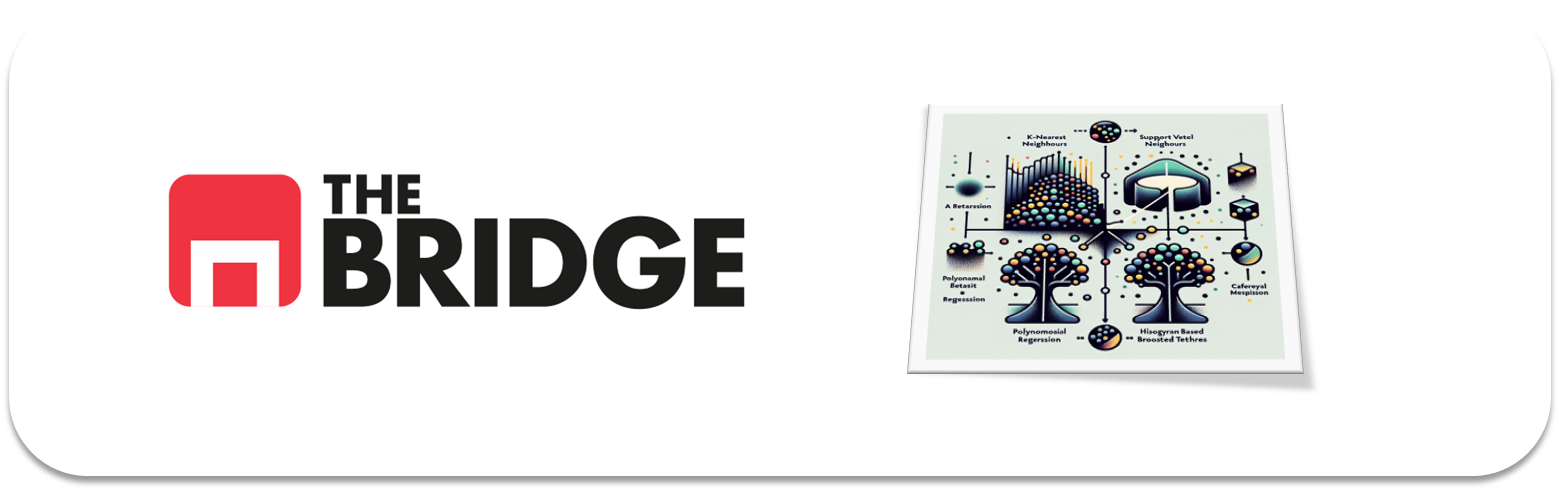

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report
import warnings
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from sklearn.metrics import recall_score

warnings.filterwarnings("ignore")

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

C:\Users\ivanm\AppData\Local\Temp\ipykernel_23228\2110074883.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  wine_data['class'] = wine_data['class'].replace({'red': 0, 'white': 1})


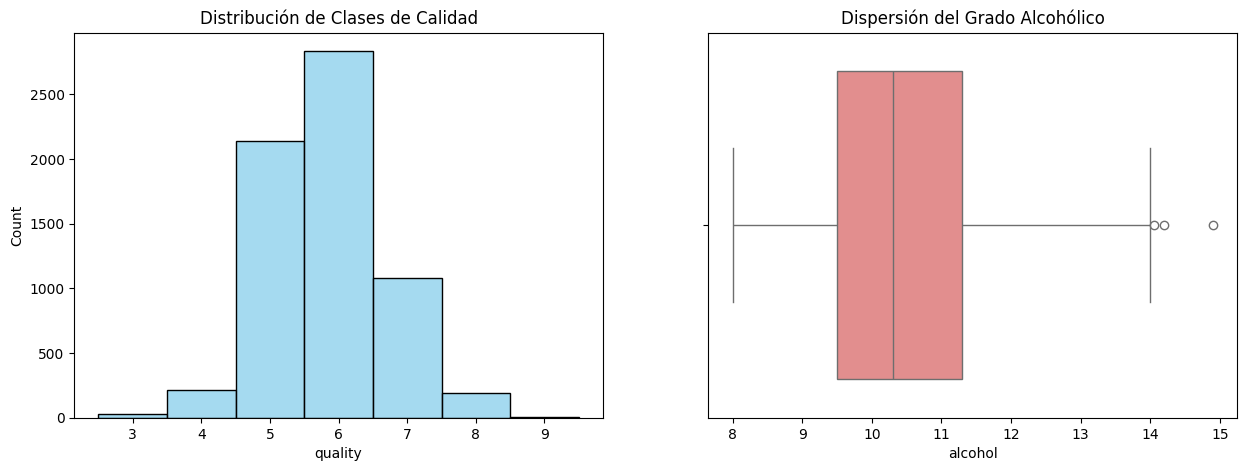

In [5]:
wine_data = pd.read_csv("./data/wines_dataset.csv", sep="|")

# Mapeo manual de la clase para evitar errores de tipos
wine_data['class'] = wine_data['class'].replace({'red': 0, 'white': 1})

# Visualización de los dos horizontes de predicción
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(wine_data['quality'], discrete=True, color='skyblue', ax=ax1)
ax1.set_title("Distribución de Clases de Calidad")

sns.boxplot(x=wine_data['alcohol'], color='lightcoral', ax=ax2)
ax2.set_title("Dispersión del Grado Alcohólico")
plt.show()


Clasificación (Calidad): El objetivo es el recall medio. Como las notas 3, 4 y 9 suelen ser raras, un modelo estándar las ignoraría. Usaremos penalización de pesos para forzar al modelo a "prestar atención" a esas minorías.

Regresión (Alcohol): Buscamos minimizar el error porcentual. Dado que el alcohol no tiene una distribución perfectamente normal, modelos basados en árboles suelen capturar mejor las relaciones no lineales que una regresión lineal simple.

In [8]:
#2 Clasificación de Calidad (Hacia el mejor Recall Medio)

# Definición de variables
X_clf = wine_data.drop(columns=['quality', 'alcohol'])
y_clf = wine_data['quality']

X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=123, stratify=y_clf)

# Escalado necesario para KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Prueba de Baseline KNN con diferentes K
for k_val in [3, 7, 11]:
    knn_mod = KNeighborsClassifier(n_neighbors=k_val)
    cv_recall = cross_val_score(knn_mod, X_train_scaled, y_train, cv=5, scoring='recall_macro').mean()
    print(f"KNN k={k_val} -> Recall Medio CV: {cv_recall:.4f}")

# Intento de mejora con Gradient Boosting (Alternativa a RF)
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=123)
gb_recall = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='recall_macro').mean()
print(f"Gradient Boosting -> Recall Medio CV: {gb_recall:.4f}")

KNN k=3 -> Recall Medio CV: 0.2981
KNN k=7 -> Recall Medio CV: 0.2617
KNN k=11 -> Recall Medio CV: 0.2461
Gradient Boosting -> Recall Medio CV: 0.3011


In [9]:

# Búsqueda aleatoria de hiperparámetros (más eficiente que GridSearch)
param_dist = {
    'n_estimators': [100, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rand_search = RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=5, cv=3, scoring='recall_macro', random_state=42)
rand_search.fit(X_train, y_train)

print("--- Evaluación del Mejor Modelo de Clasificación ---")
final_preds = rand_search.best_estimator_.predict(X_test)
print(classification_report(y_test, final_preds))

--- Evaluación del Mejor Modelo de Clasificación ---
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.25      0.37      0.30        43
           5       0.57      0.68      0.62       428
           6       0.62      0.37      0.46       567
           7       0.45      0.73      0.56       216
           8       0.43      0.38      0.41        39
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1300
   macro avg       0.33      0.36      0.34      1300
weighted avg       0.55      0.53      0.52      1300



In [ ]:
#3 Regresión del Grado Alcohólico

from sklearn.ensemble import RandomForestRegressor

# En este caso 'quality' actúa como una característica más
X_reg = wine_data.drop(columns=['alcohol'])
y_reg = wine_data['alcohol']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Modelo de Regresión
reg_model = RandomForestRegressor(n_estimators=200, random_state=42)
reg_model.fit(X_train_r, y_train_r)

# Predicción y cálculo de la métrica de negocio (MAPE)
preds_reg = reg_model.predict(X_test_r)
mape_score = mean_absolute_percentage_error(y_test_r, preds_reg)

print(f"MAPE del modelo de Alcohol: {mape_score:.2%}")

MAPE del modelo de Alcohol: 2.49%


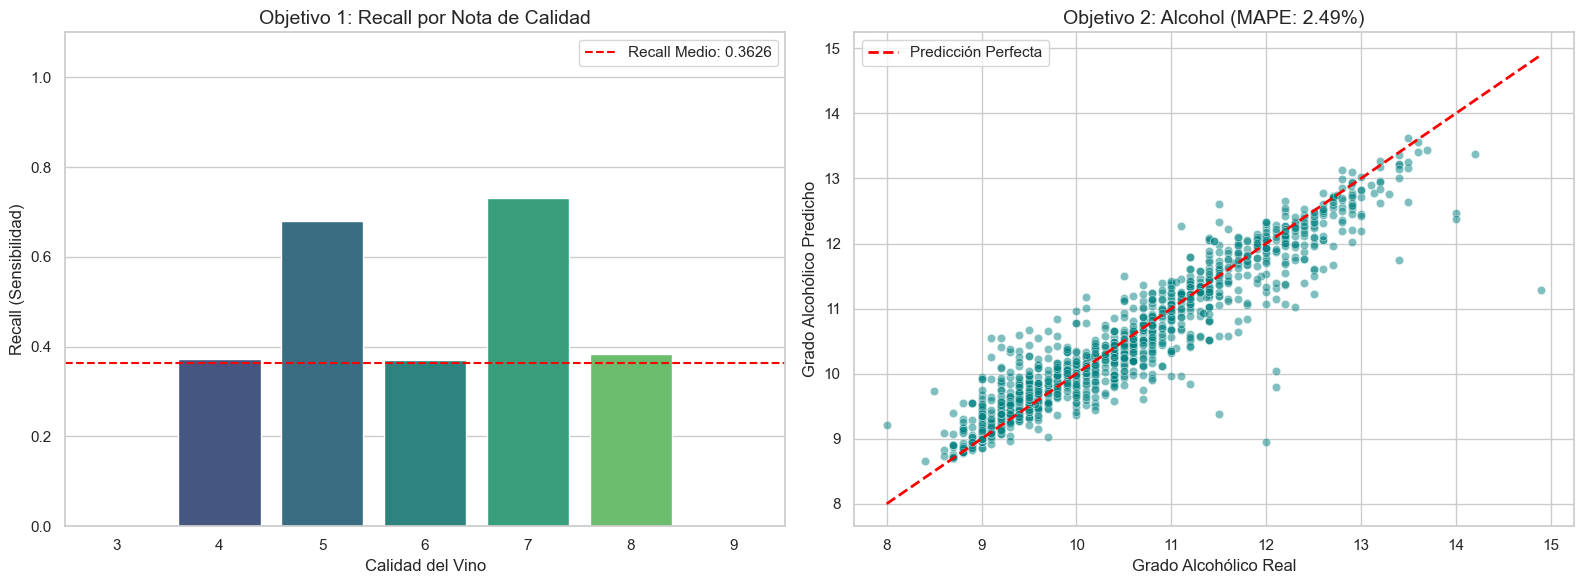

In [ ]:

from sklearn.metrics import recall_score, mean_absolute_percentage_error

# 1. Configuración de avisos y estilo
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# 2. Aseguramos el cálculo de las métricas para evitar NameError

try:
    # Cálculo de métrica para el título de regresión
    mape_val = mean_absolute_percentage_error(y_test_r, preds_reg)
    
    # Cálculo de métricas para clasificación
    calidades = sorted(y_test.unique())
    recalls = recall_score(y_test, final_preds, average=None, labels=calidades)
    recall_medio = np.mean(recalls)

    # 3. Creación del lienzo doble
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # SUBPLOT 1: CLASIFICACIÓN (RECALL POR CLASE)
    sns.barplot(x=calidades, y=recalls, palette="viridis", ax=ax1)
    ax1.axhline(y=recall_medio, color='red', linestyle='--', 
                label=f'Recall Medio: {recall_medio:.4f}')
    ax1.set_title("Objetivo 1: Recall por Nota de Calidad", fontsize=14)
    ax1.set_xlabel("Calidad del Vino", fontsize=12)
    ax1.set_ylabel("Recall (Sensibilidad)", fontsize=12)
    ax1.set_ylim(0, 1.1) # Espacio para la etiqueta
    ax1.legend()

    # SUBPLOT 2: REGRESIÓN (REAL VS PREDICHO)
    sns.scatterplot(x=y_test_r, y=preds_reg, alpha=0.5, color="teal", ax=ax2)
    
    # Línea de identidad (Referencia de predicción perfecta)
    lims = [min(y_test_r.min(), preds_reg.min()), max(y_test_r.max(), preds_reg.max())]
    ax2.plot(lims, lims, color='red', lw=2, linestyle='--', label="Predicción Perfecta")
    
    ax2.set_title(f"Objetivo 2: Alcohol (MAPE: {mape_val:.2%})", fontsize=14)
    ax2.set_xlabel("Grado Alcohólico Real", fontsize=12)
    ax2.set_ylabel("Grado Alcohólico Predicho", fontsize=12)
    ax2.legend()

    plt.tight_layout()
    plt.show()

except NameError as e:
    print(f"Error: Asegúrate de haber ejecutado las celdas de entrenamiento antes. Detalles: {e}")

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, mean_absolute_percentage_error

# Preparación de datos (limpieza mínima: convertir 'class' a numérico)
df['class'] = df['class'].map({'red': 0, 'white': 1})
X = df.drop(columns=['quality', 'alcohol'])
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado para KNN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


for k in [3, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Scoring recall_macro es equivalente al recall medio pedido
    cv_score = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring='recall_macro').mean()
    print(f"KNN (K={k}) - Recall Medio CV: {cv_score:.4f}")

# Modelo Elegido y Optimización: Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'class_weight': ['balanced'] # Técnica para mejorar el recall en clases difíciles
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall_macro')
grid.fit(X_train, y_train)

# Evaluación Final
y_pred = grid.best_estimator_.predict(X_test)
print("\nMejores parámetros:", grid.best_params_)
print("\nReporte de Clasificación (Final):")
print(classification_report(y_test, y_pred))

KNN (K=3) - Recall Medio CV: 0.2930
KNN (K=7) - Recall Medio CV: 0.2712

Mejores parámetros: {'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 200}

Reporte de Clasificación (Final):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.26      0.26      0.26        43
           5       0.62      0.72      0.67       428
           6       0.66      0.47      0.55       567
           7       0.44      0.65      0.53       216
           8       0.35      0.33      0.34        39
           9       0.00      0.00      0.00         1

    accuracy                           0.57      1300
   macro avg       0.33      0.35      0.34      1300
weighted avg       0.59      0.57      0.57      1300



### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [27]:


# Definimos claramente los targets
target_reg = 'alcohol'

# Separación de datos para regresión (usamos los mismos X de antes pero con y de alcohol)
y_reg = wine_data[target_reg]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_clf, y_reg, test_size=0.2, random_state=42)

# Entrenamiento
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)

# Predicciones y Métricas
preds_reg = reg_model.predict(X_test_r)
mape_val = mean_absolute_percentage_error(y_test_r, preds_reg)
mae_val = mean_absolute_error(y_test_r, preds_reg)
r2_val = r2_score(y_test_r, preds_reg)

print("MÉTRICAS FINALES (ALCOHOL)")
print(f"MAPE: {mape_val:.4%}")
print(f"MAE: {mae_val:.4f} grados")
print(f"R2 Score: {r2_val:.4f}")

MÉTRICAS FINALES (ALCOHOL)
MAPE: 2.5020%
MAE: 0.2645 grados
R2 Score: 0.8830


In [25]:
# Definición de variables: Para predecir alcohol, 'quality' se usa como feature
X_reg = df.drop(columns=['alcohol'])
y_reg = df['alcohol']

# Split de datos
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Entrenamiento del modelo
reg_model = RandomForestRegressor(n_estimators=100, random_state=42)
reg_model.fit(X_train_r, y_train_r)

# Predicciones
y_pred_r = reg_model.predict(X_test_r)

MÉTRICAS FINALES (ALCOHOL)
MAPE: 2.5178%
MAE: 0.2659 grados
R2 Score: 0.8842


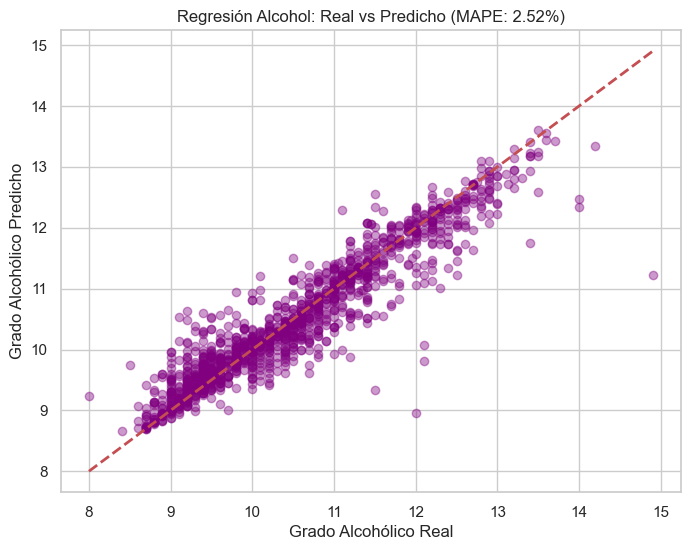

In [28]:
# Cálculo de métricas
mape = mean_absolute_percentage_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("MÉTRICAS FINALES (ALCOHOL)")
print(f"MAPE: {mape:.4%}") 
print(f"MAE: {mae:.4f} grados")
print(f"R2 Score: {r2:.4f}")

# Gráfico de Real vs Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.4, color='purple')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--', lw=2) # Línea de perfección
plt.title(f"Regresión Alcohol: Real vs Predicho (MAPE: {mape:.2%})")
plt.xlabel("Grado Alcohólico Real")
plt.ylabel("Grado Alcohólico Predicho")
plt.show()